# Diagnosing segmentation quality

**Day 1 · Session 2.1**

Segmentation is upstream of everything. If two cells are merged into one, that merged object
gets a gene expression profile, survives normalisation, clusters somewhere, and comes out the
other end looking like a novel intermediate cell state. Nothing downstream will tell you it
is an artifact — it looks exactly like biology.

So before any analysis: **is this segmentation any good?**

### What you will be able to do afterwards

- Compute the five metrics that actually diagnose an imaging-based segmentation
- Read each of them **as a spatial map**, not only as a histogram
- Choose and defend a filter, and say which cells you just threw away

## Setup

In [1]:
%matplotlib inline

import pathlib
import sys

# Find the repository root (the directory holding paths.py) and make it importable.
# Safe to re-run: unlike %cd, this does not move anywhere.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401

import paths

sdata = sd.read_zarr(paths.data("xenium_breast_2fov.zarr"))
adata = sdata["table"]
adata

no parent found for <ome_zarr.reader.Label object at 0x171eee990>: None


no parent found for <ome_zarr.reader.Label object at 0x1730bdbe0>: None


AnnData object with n_obs × n_vars = 7275 × 280
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X)

## 1. What the vendor already gave us

Xenium ships per-cell measurements alongside the counts. Several of them are QC metrics that
you would otherwise have to compute yourself.

In [3]:
adata.obs.head()

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
aaaiikim-1,aaaiikim-1,66,0,0,0,0,66,58.477346,34.860626,cell_labels,0.0,1.0,1
aaaljapa-1,aaaljapa-1,95,0,0,0,0,95,77.217190,59.696565,cell_labels,0.0,1.0,2
aabhbgmg-1,aabhbgmg-1,215,0,0,0,0,215,116.187035,73.198284,cell_labels,0.0,1.0,3
aabpgobe-1,aabpgobe-1,103,0,0,0,0,103,71.166253,56.219533,cell_labels,0.0,1.0,4
aacemgol-1,aacemgol-1,95,0,0,0,0,95,99.343754,NaN,cell_labels,0.0,0.0,5


| Column | What it is |
|---|---|
| `transcript_counts` | real gene transcripts assigned to this cell |
| `control_probe_counts` | negative control **probes** — chemistry background |
| `control_codeword_counts` | negative control **codewords** — decoding background |
| `unassigned_codeword_counts` | codewords that decoded to nothing in the panel |
| `total_counts` | the sum of the above |
| `cell_area`, `nucleus_area` | in um^2 |
| `nucleus_count` | how many nuclei the segmentation put inside this cell |

That last one is a gift: a cell with **zero** nuclei or **more than one** is, by definition,
a segmentation that disagrees with itself.

In [4]:
adata.obs["nucleus_count"].value_counts().sort_index()

nucleus_count
0.0     255
1.0    6752
2.0     246
3.0      20
4.0       2
Name: count, dtype: int64

> **_Question:_** Before looking further — should cells with two nuclei be deleted, kept, or
> flagged? Does your answer change if the tissue is tumour rather than normal breast?

## 2. The standard scanpy metrics

`sc.pp.calculate_qc_metrics` works on the table exactly as it would on any scRNA-seq object.

Two things to notice. First, it **overwrites** `total_counts` — same quantity, but recomputed
from `.X` instead of reported by the instrument. Second, and more important:

In [5]:
n_control_features = adata.var_names.str.startswith(
    ("NegControlProbe", "NegControlCodeword", "UnassignedCodeword", "DeprecatedCodeword", "BLANK")
).sum()
print(f"{adata.n_vars} features in the table, of which {n_control_features} are negative controls")

280 features in the table, of which 0 are negative controls


Zero. The table has already been cleaned for you: it holds the 280 real panel genes and
nothing else. The negative controls survive in exactly two places — as the per-cell summary
columns in `.obs`, and as individual rows in the points element.

This is why you cannot do imaging-based QC from the table alone, and why §4 below goes back
to the transcripts.

In [6]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, inplace=True, log1p=False)
adata.obs[["total_counts", "n_genes_by_counts"]].describe()

,total_counts,n_genes_by_counts
count,7275.000000,7275.000000
mean,123.219383,44.646598
std,84.889740,18.243158
min,0.000000,0.000000
25%,54.000000,30.000000
50%,109.000000,46.000000
75%,174.000000,59.000000
max,673.000000,112.000000


## 3. Metric 1 — transcripts per cell

The distribution you always look at first. In imaging-based data the interesting part is the
**low tail**: objects with almost no transcripts are usually debris, fragments at the section
edge, or empty polygons where segmentation fired on nothing.

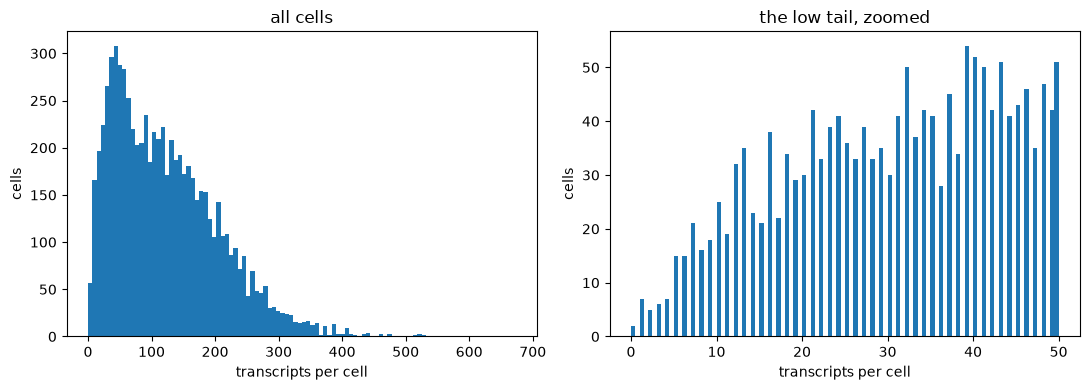

median 109 transcripts per cell
112 cells below 10 transcripts
2 cells with nothing at all


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].hist(adata.obs["total_counts"], bins=100)
axs[0].set(xlabel="transcripts per cell", ylabel="cells", title="all cells")
axs[1].hist(adata.obs["total_counts"], bins=100, range=(0, 50))
axs[1].set(xlabel="transcripts per cell", ylabel="cells", title="the low tail, zoomed")
plt.tight_layout()
plt.show()

print(f"median {adata.obs['total_counts'].median():.0f} transcripts per cell")
print(f"{(adata.obs['total_counts'] < 10).sum()} cells below 10 transcripts")
print(f"{(adata.obs['total_counts'] == 0).sum()} cells with nothing at all")

Now the same quantity **in space**. Remember from Session 1 that the table annotates
`cell_labels`, so that is the element we colour.

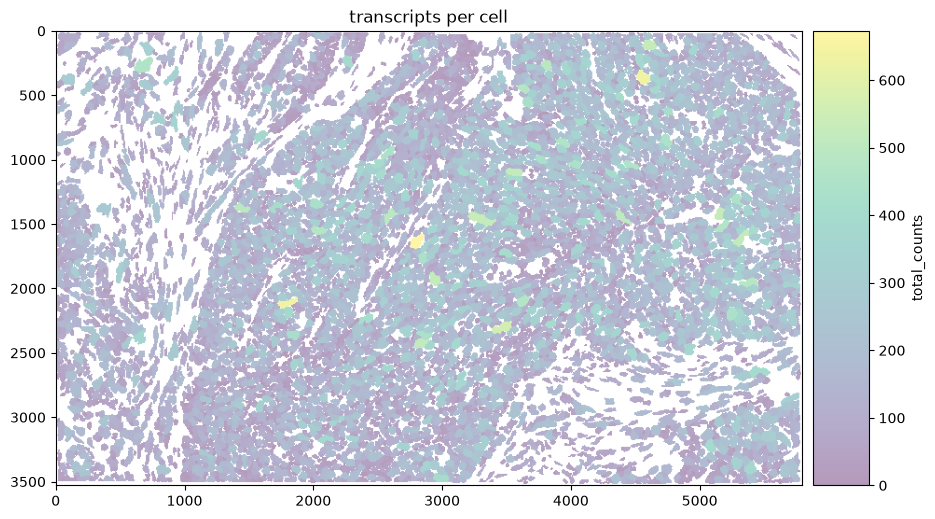

In [8]:
sdata.pl.render_labels("cell_labels", color="total_counts").pl.show(
    coordinate_systems="global", title="transcripts per cell", figsize=(8, 6)
)

## 4. Metric 2 — transcript assignment rate

**If you only ever compute one number, compute this one.**

Every transcript detection either lands inside a cell boundary or it does not. The fraction
that does is the clearest single statement about whether your segmentation is capturing the
tissue. Unassigned transcripts are signal you paid for and cannot use.

This is computed on the *points* element, not the table — the table only ever knew about
transcripts that were successfully assigned.

In [9]:
points = sdata["transcripts"][["cell_id", "qv", "feature_name"]].compute()

cell_id = points["cell_id"].astype(str)
feature = points["feature_name"].astype(str)
is_negative = feature.str.startswith(
    ("NegControlProbe", "NegControlCodeword", "UnassignedCodeword", "DeprecatedCodeword", "BLANK")
)
is_assigned = (cell_id != "UNASSIGNED").to_numpy()
passes_qv = (points["qv"].to_numpy() >= 20)

print(f"transcripts total      {len(points):,}")
print(f"negative controls      {is_negative.sum():,} ({is_negative.mean():.2%})")
print(f"qv >= 20               {passes_qv.mean():.1%}")
print()
print(f"assignment rate, all transcripts        {is_assigned.mean():.1%}")
keep = (~is_negative.to_numpy()) & passes_qv
print(f"assignment rate, real genes at qv >= 20 {is_assigned[keep].mean():.1%}")

transcripts total      1,113,950
negative controls      2,471 (0.22%)
qv >= 20               93.0%

assignment rate, all transcripts        86.5%
assignment rate, real genes at qv >= 20 86.6%


Around 87% here, and the two numbers barely differ — quality filtering does not rescue the
unassigned fraction, which tells you the loss is spatial (transcripts genuinely outside any
boundary) rather than a decoding problem.

There is no universal threshold here — the achievable rate depends on the panel, the tissue,
and how much cytoplasm the segmentation captures. As rough orientation on Xenium-like data,
healthy runs usually land somewhere in the **70–90%** range, and anything below **50%** is a
reason to stop and look at the segmentation before analysing anything. What matters more than
the absolute number is comparing it **between segmentations of the same tissue**, which is
exactly what the next notebook does.

> **_Question:_** Your assignment rate is 70%. Name three different causes — one about
> segmentation, one about chemistry, one about the tissue — and one measurement that would
> distinguish them.

Where the unassigned transcripts *are* matters as much as how many. Diffuse everywhere means
bleed; concentrated in patches means segmentation failed on a specific region or cell type.

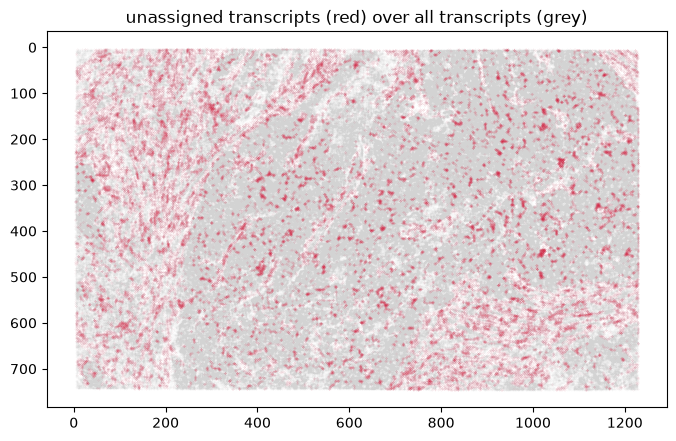

In [10]:
xy = sdata["transcripts"][["x", "y", "cell_id"]].compute()
unassigned = xy[xy["cell_id"].astype(str) == "UNASSIGNED"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(xy["x"], xy["y"], s=0.05, alpha=0.05, color="lightgrey", rasterized=True)
ax.scatter(unassigned["x"], unassigned["y"], s=0.05, alpha=0.08, color="crimson", rasterized=True)
ax.set(title="unassigned transcripts (red) over all transcripts (grey)", aspect="equal")
ax.invert_yaxis()
plt.show()

## 5. Metric 3 — cell area and the nucleus:cell ratio

Area alone catches empty and giant polygons. The **ratio** of nucleus area to cell area is
the more diagnostic quantity:

- ratio near **1** — the segmentation never expanded past the nucleus, so you are measuring
  nuclear transcripts only and losing cytoplasm
- ratio very **low** — the boundary was expanded far past the nucleus and is probably
  swallowing neighbours' transcripts

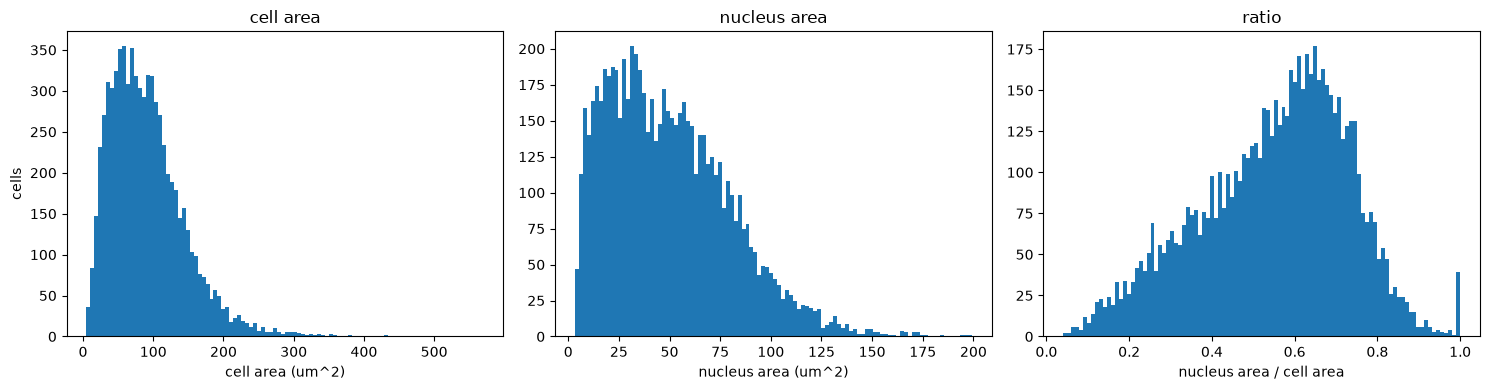

,cell_area,nucleus_area,nucleus_cell_ratio
count,7275.000000,7020.000000,7020.000000
mean,91.268748,49.803306,0.550128
std,53.323052,30.275354,0.179238
min,4.876875,3.251250,0.040554
25%,52.403830,25.547149,0.429209
50%,83.042347,45.878752,0.574919
75%,119.054457,69.247112,0.680901
max,570.142833,199.184226,1.000000


In [11]:
adata.obs["nucleus_cell_ratio"] = adata.obs["nucleus_area"] / adata.obs["cell_area"]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(adata.obs["cell_area"], bins=100)
axs[0].set(xlabel="cell area (um^2)", ylabel="cells", title="cell area")
axs[1].hist(adata.obs["nucleus_area"], bins=100)
axs[1].set(xlabel="nucleus area (um^2)", title="nucleus area")
axs[2].hist(adata.obs["nucleus_cell_ratio"], bins=100)
axs[2].set(xlabel="nucleus area / cell area", title="ratio")
plt.tight_layout()
plt.show()

adata.obs[["cell_area", "nucleus_area", "nucleus_cell_ratio"]].describe()

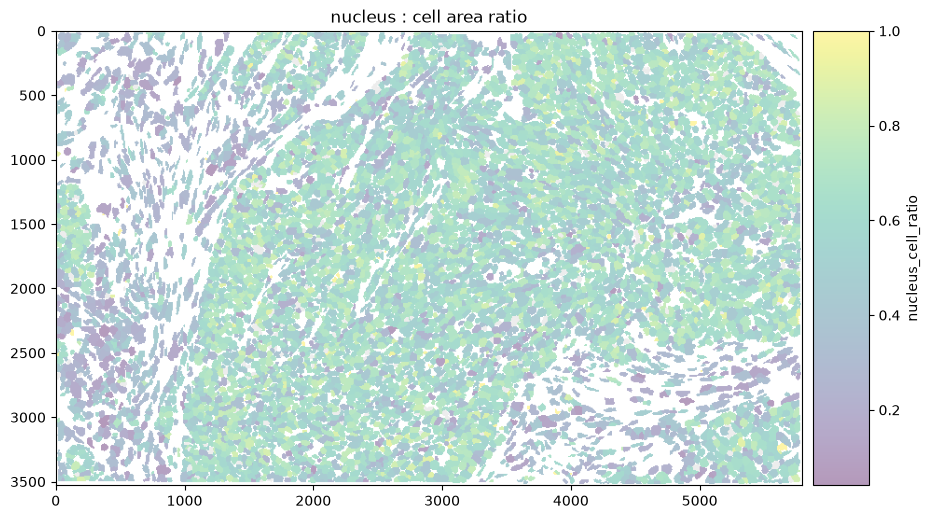

In [12]:
sdata.pl.render_labels("cell_labels", color="nucleus_cell_ratio").pl.show(
    coordinate_systems="global", title="nucleus : cell area ratio", figsize=(8, 6)
)

## 6. Metric 4 — counts versus area

A tight straight line through the origin means the number of transcripts you measure is
essentially a function of how big the polygon is. That is what transcript bleed looks like:
a bigger boundary simply sweeps up more of a diffuse background.

Real biology is messier than that — cell types differ in transcriptional output at the same
size, so you expect spread.

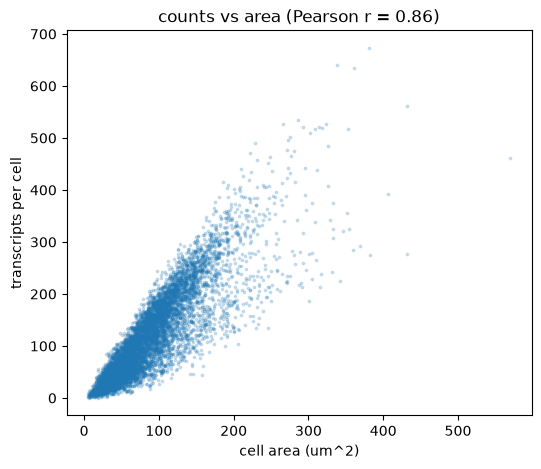

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(adata.obs["cell_area"], adata.obs["total_counts"], s=3, alpha=0.2)
ax.set(xlabel="cell area (um^2)", ylabel="transcripts per cell", title="counts vs area")

r = np.corrcoef(adata.obs["cell_area"], adata.obs["total_counts"])[0, 1]
ax.set_title(f"counts vs area (Pearson r = {r:.2f})")
plt.show()

> **_Question:_** Your counts-vs-area scatter is a clean straight line with r = 0.95. Good
> news or bad news?

## 7. Metric 5 — negative control rate

Negative control probes and codewords cannot be real signal, so whatever fraction of a cell's
counts they represent is a direct estimate of that cell's background. High background in a
specific region usually means an imaging or tissue problem there, not a biological one.

In [14]:
control_cols = ["control_probe_counts", "control_codeword_counts", "unassigned_codeword_counts"]
adata.obs["control_fraction"] = (
    adata.obs[control_cols].sum(axis=1) / adata.obs["total_counts"].clip(lower=1)
)

print(adata.obs["control_fraction"].describe())
print(f"\ncells above 5% control: {(adata.obs['control_fraction'] > 0.05).sum()}")

count    7275.000000
mean        0.000568
std         0.003519
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.142857
Name: control_fraction, dtype: float64

cells above 5% control: 5


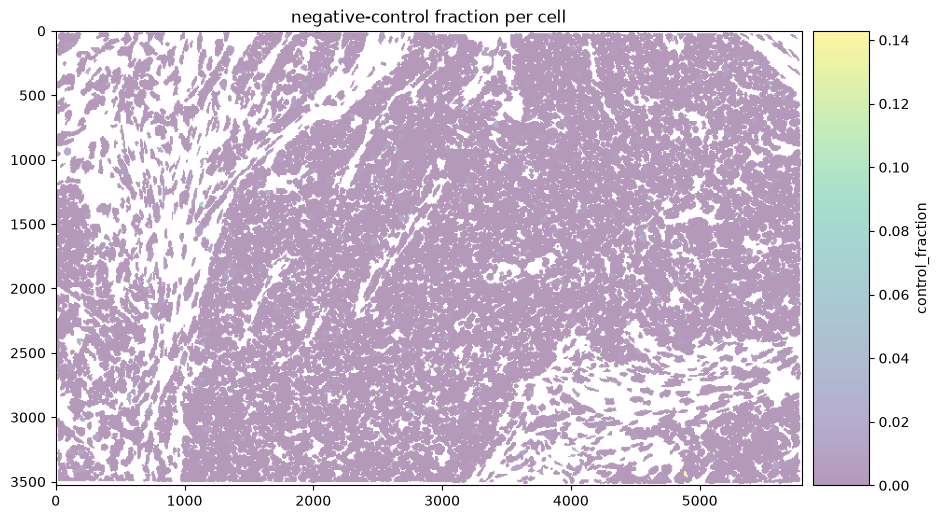

In [15]:
sdata.pl.render_labels("cell_labels", color="control_fraction").pl.show(
    coordinate_systems="global", title="negative-control fraction per cell", figsize=(8, 6)
)

## 8. All of it, in space

This is the point of the session. Each of these metrics has a perfectly unremarkable
histogram. Side by side as spatial maps, structure appears — and **structure is what tells
you an artifact is an artifact**, because real biology and instrument failure look different
in space even when they look identical in a distribution.

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_1524/2030199596.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


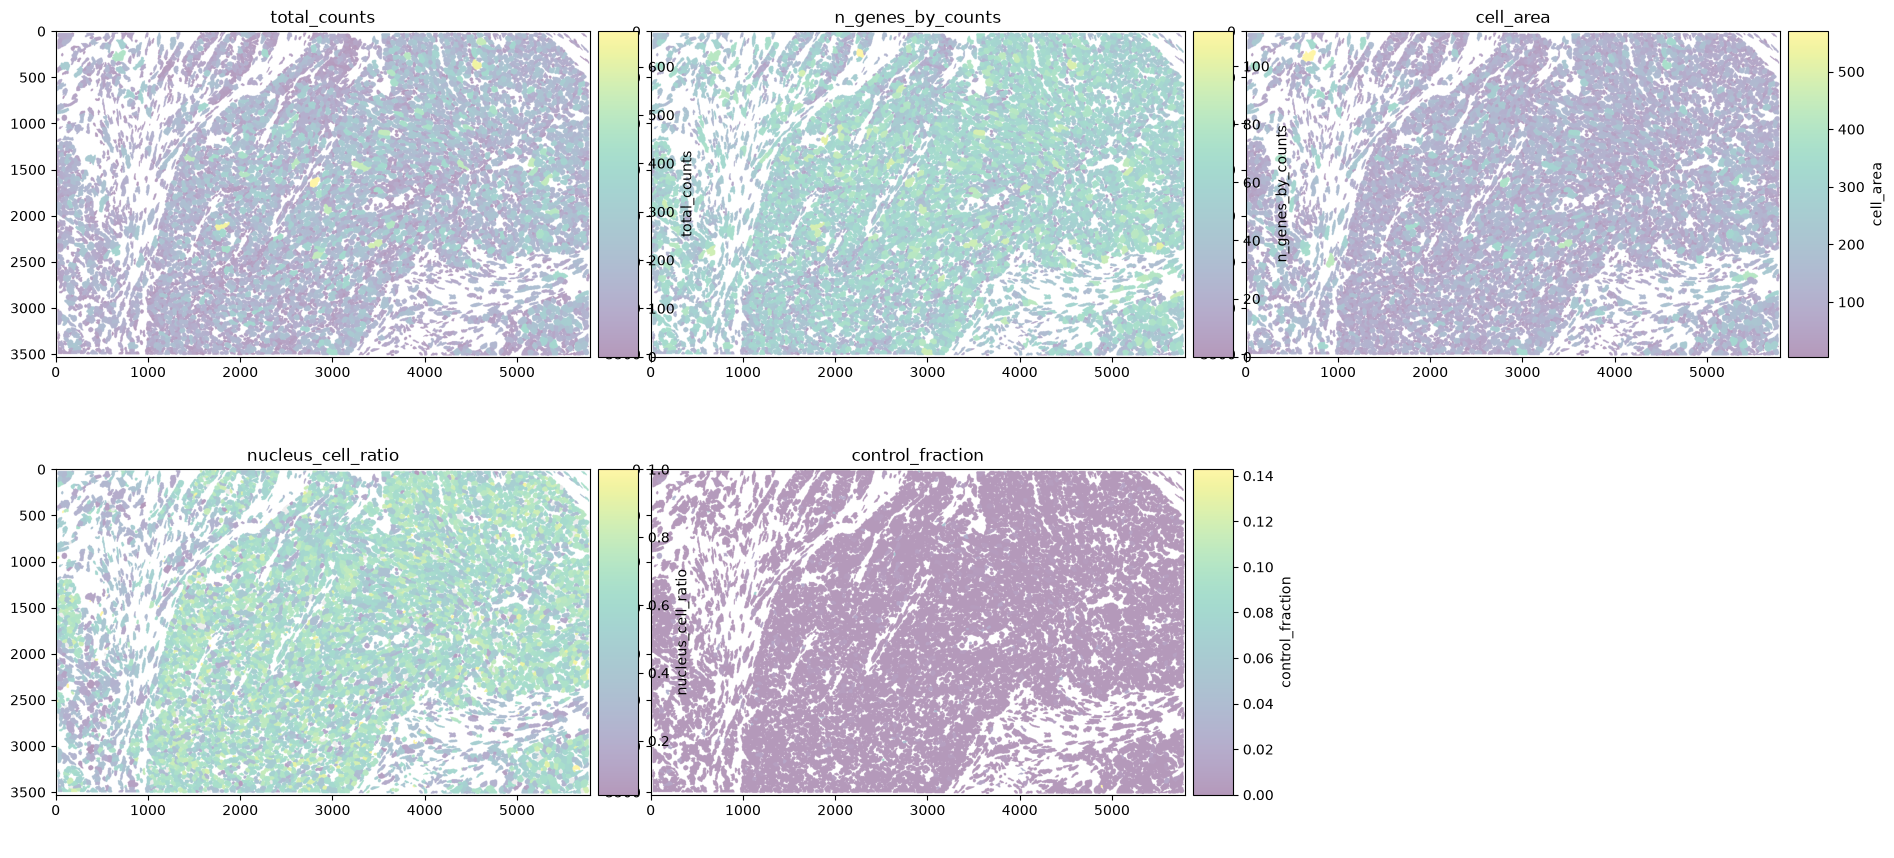

In [16]:
metrics = ["total_counts", "n_genes_by_counts", "cell_area", "nucleus_cell_ratio", "control_fraction"]

fig, axs = plt.subplots(2, 3, figsize=(18, 9))
for ax, metric in zip(axs.flat, metrics):
    sdata.pl.render_labels("cell_labels", color=metric).pl.show(
        coordinate_systems="global", ax=ax, title=metric, colorbar=True
    )
axs.flat[-1].axis("off")
plt.tight_layout()
plt.show()

## 9. Filter — and look at what you removed

Any filter is a claim about which objects are not cells. Make the claim explicit, then look
at what it deleted. If the removed set is spatially clustered, you have either found a real
bad region or written a filter that deletes a cell type.

In [17]:
keep = (
    (adata.obs["total_counts"] >= 10)
    & (adata.obs["nucleus_count"] >= 1)
    & (adata.obs["control_fraction"] <= 0.05)
)
adata.obs["qc_pass"] = pd.Categorical(np.where(keep, "pass", "fail"))

print(adata.obs["qc_pass"].value_counts())
print(f"\nremoving {(~keep).sum()} of {len(keep)} cells ({(~keep).mean():.1%})")

qc_pass
pass    6906
fail     369
Name: count, dtype: int64

removing 369 of 7275 cells (5.1%)


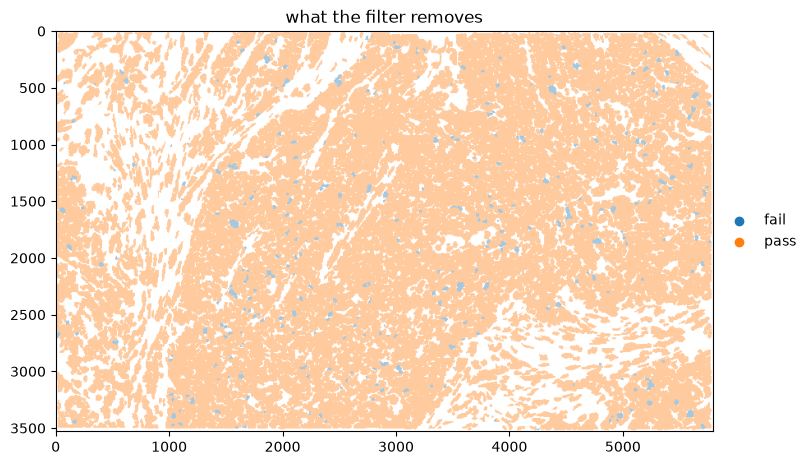

In [18]:
sdata.pl.render_labels("cell_labels", color="qc_pass").pl.show(
    coordinate_systems="global", title="what the filter removes", figsize=(8, 6)
)

In [19]:
# What did we actually delete? Compare the two groups rather than trusting the threshold.
adata.obs.groupby("qc_pass", observed=True)[
    ["total_counts", "n_genes_by_counts", "cell_area", "nucleus_cell_ratio"]
].median()

,total_counts,n_genes_by_counts,cell_area,nucleus_cell_ratio
qc_pass,,,,
fail,46.0,26.0,34.725158,0.657397
pass,114.0,47.0,86.022659,0.573985


The filtered object is what Session 3 will build the spatial graph on, so save it to **your**
output directory — the shared data directory is read-only.

In [20]:
adata_qc = adata[keep].copy()
adata_qc.write(paths.OUT / "xenium_qc_filtered.h5ad")
print(f"{adata_qc.n_obs} cells kept -> {paths.OUT / 'xenium_qc_filtered.h5ad'}")

6906 cells kept -> /home/user1/2026_09_workshop_physalia/outputs/xenium_qc_filtered.h5ad


### Exercise

1. Pick a different threshold on `total_counts` than the 10 used above. Plot the removed
   cells spatially. At what threshold do you start deleting a *region* rather than scattered
   objects?
2. Add a filter on `nucleus_cell_ratio`. Justify both ends of it from the histogram in §5.
3. Compute the median `total_counts` of the cells you removed. If it is not much lower than
   the cells you kept, what does that tell you about your filter?
4. Compare `transcript_counts` (vendor) with `total_counts` (scanpy). Do they agree? If not,
   which features account for the difference?

> **_Question:_** Which real cell population did your filter just preferentially delete, and
> how would you notice if it had?

In [21]:
# your answer here

## Pitfalls

- **Do not copy a scRNA-seq QC recipe.** `pct_counts_mt` is meaningless here: there are no
  mitochondrial genes in a 280-gene targeted panel. The negative-control fraction is the
  imaging-based equivalent, and it measures something different.
- **Counts-only filters delete small cells first.** Lymphocytes are small and quiet; an
  aggressive `min_counts` removes immune infiltration and leaves you concluding there was
  none.
- **A histogram cannot show you a bad tissue region.** Always map the metric.
- **Filtering the table does not filter the elements.** The labels and boundaries still
  contain every object. That is fine — but remember it when you plot.

## Further reading

- [10x Xenium algorithms: cell segmentation and QC](https://www.10xgenomics.com/support/software/xenium-onboard-analysis/latest/algorithms-overview)
- [Squidpy QC tutorial for imaging-based data](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_xenium.html)
- [Marconato et al. (2024), *SpatialData*, Nature Methods](https://www.nature.com/articles/s41592-024-02212-x)